In [ ]:
import tensorflow as tf
from tensorflow.keras import layers,models
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
(train_images, train_lables),(test_images,test_lables) = tf.keras.datasets.mnist.load_data()

In [ ]:
train_images,test_images = train_images/255.0 , test_images/255.0

In [ ]:
train_images = train_images[:2000]
train_lables = train_lables[:2000]
test_images = test_images[:2000]
test_lables = test_lables[:2000]

train_images = train_images.reshape((train_images.shape[0],28,28,1))
test_images = test_images.reshape((test_images.shape[0],28,28,1))

1. Drop Out


In [ ]:
model = models.Sequential([
    layers.Conv2D(32,(3,3),activation ='relu',input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu'),

    layers.Flatten(),
    layers.Dense(64,activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(10,activation='softmax')

])

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(train_images, train_lables,epochs = 10,validation_data = (test_images , test_lables))


Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.2733 - loss: 2.0310 - val_accuracy: 0.7905 - val_loss: 0.7643
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.6992 - loss: 0.9103 - val_accuracy: 0.8570 - val_loss: 0.4398
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.8435 - loss: 0.5172 - val_accuracy: 0.9090 - val_loss: 0.3175
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.8648 - loss: 0.4089 - val_accuracy: 0.9155 - val_loss: 0.2616
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.9024 - loss: 0.3255 - val_accuracy: 0.9210 - val_loss: 0.2586
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.9191 - loss: 0.2548 - val_accuracy: 0.9345 - val_loss: 0.2172
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.9309 - loss: 0.2302 - val_accuracy: 0.9330 - val_loss: 0.2091
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.9436 - loss: 0.1816 - val_accuracy: 0.9385 - v

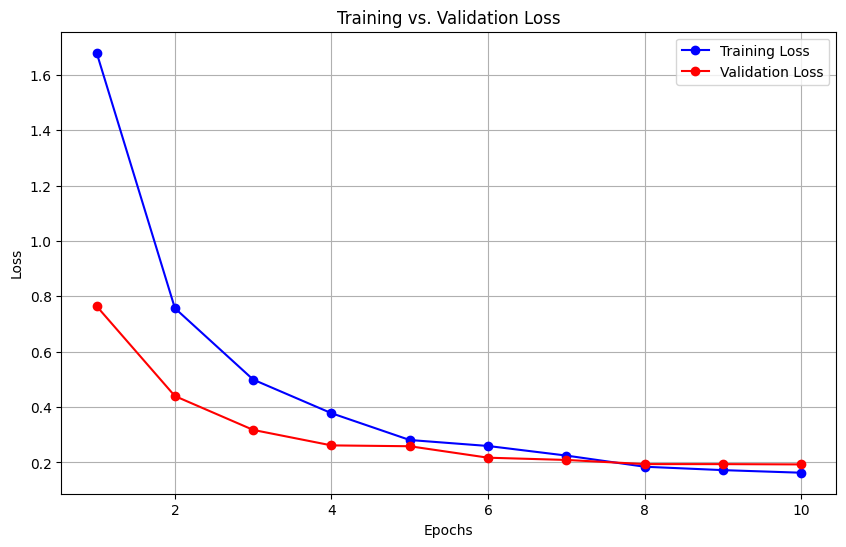

In [ ]:
import matplotlib.pyplot as plt

train_loss = history.history['loss']
val_loss = history.history['val_loss']


epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_loss, 'bo-', label='Training Loss')    # 'bo-' gives blue dots with lines
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')    # 'ro-' gives red dots with lines

# 3. Label the chart
plt.title('Training vs. Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 4. Display
plt.show()

2. L2 regularization


In [ ]:
from tensorflow.keras import regularizers

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1),
                  kernel_regularizer=regularizers.l2(0.001)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu',
                  kernel_regularizer=regularizers.l2(0.001)),
    layers.MaxPooling2D((2, 2)),

    # Conv Layer 3 with L2
    layers.Conv2D(64, (3, 3), activation='relu',
                  kernel_regularizer=regularizers.l2(0.001)),

    layers.Flatten(),
    layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),

    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train
history = model.fit(train_images, train_lables, epochs=10,
                    validation_data=(test_images, test_lables))

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.4433 - loss: 1.9267 - val_accuracy: 0.8145 - val_loss: 0.7864
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.8676 - loss: 0.5952 - val_accuracy: 0.8785 - val_loss: 0.5587
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.9446 - loss: 0.3709 - val_accuracy: 0.8585 - val_loss: 0.5983
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.9501 - loss: 0.3490 - val_accuracy: 0.9060 - val_loss: 0.4644
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9584 - loss: 0.3077 - val_accuracy: 0.9420 - val_loss: 0.3584
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.9786 - loss: 0.2586 - val_accuracy: 0.9445 - val_loss: 0.3467
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.9781 - loss: 0.2339 - val_accuracy: 0.9365 - val_loss: 0.3653
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9867 - loss: 0.2246 - val_accuracy: 0.9465 - v

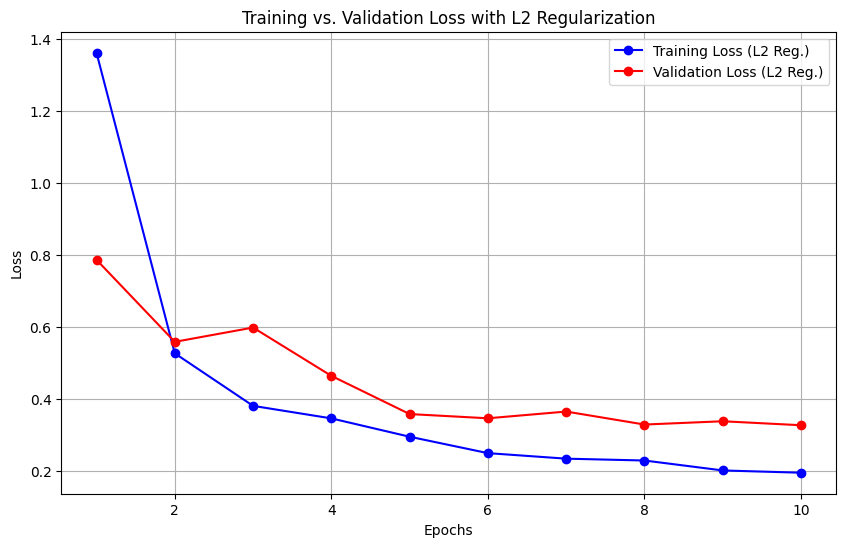

In [ ]:
import matplotlib.pyplot as plt

train_loss_l2 = history.history['loss']
val_loss_l2 = history.history['val_loss']

epochs_l2 = range(1, len(train_loss_l2) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_l2, train_loss_l2, 'bo-', label='Training Loss (L2 Reg.)')
plt.plot(epochs_l2, val_loss_l2, 'ro-', label='Validation Loss (L2 Reg.)')

plt.title('Training vs. Validation Loss with L2 Regularization')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

3. Batch **Normalization**

In [ ]:
model = models.Sequential([
    # Block 1
    layers.Conv2D(32, (3, 3), use_bias=False, input_shape=(28, 28, 1)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(64, (3, 3), use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Flatten(),

    # Dense Block
    layers.Dense(64, use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('relu'),


    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train
history = model.fit(train_images, train_lables, epochs=10,
                    validation_data=(test_images, test_lables))

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - accuracy: 0.6698 - loss: 1.1688 - val_accuracy: 0.1170 - val_loss: 2.4206
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.9541 - loss: 0.2570 - val_accuracy: 0.1170 - val_loss: 3.1423
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - accuracy: 0.9860 - loss: 0.1111 - val_accuracy: 0.1170 - val_loss: 3.6724
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.9946 - loss: 0.0747 - val_accuracy: 0.1170 - val_loss: 3.7757
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.9980 - loss: 0.0399 - val_accuracy: 0.1380 - val_loss: 3.3987
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - accuracy: 1.0000 - loss: 0.0289 - val_accuracy: 0.2420 - val_loss: 2.7693
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - accuracy: 0.9978 - loss: 0.0277 - val_accuracy: 0.4735 - val_loss: 1.5744
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 1.0000 - loss: 0.0143 - val_accuracy: 0.7205 - v

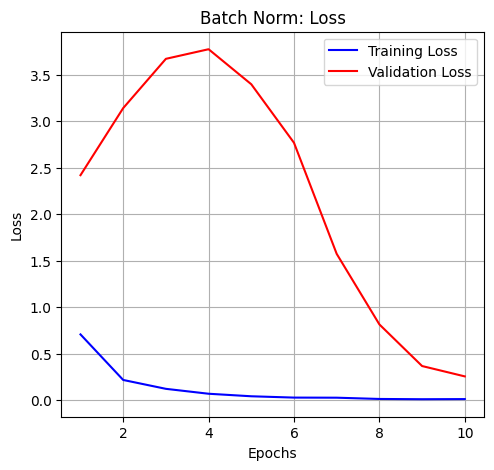

In [ ]:
import matplotlib.pyplot as plt

# Retrieve loss values
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochs = range(1, len(train_loss) + 1)

# Plot Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, 'b-', label='Training Loss')
plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
plt.title('Batch Norm: Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)


plt.show()

Comparison

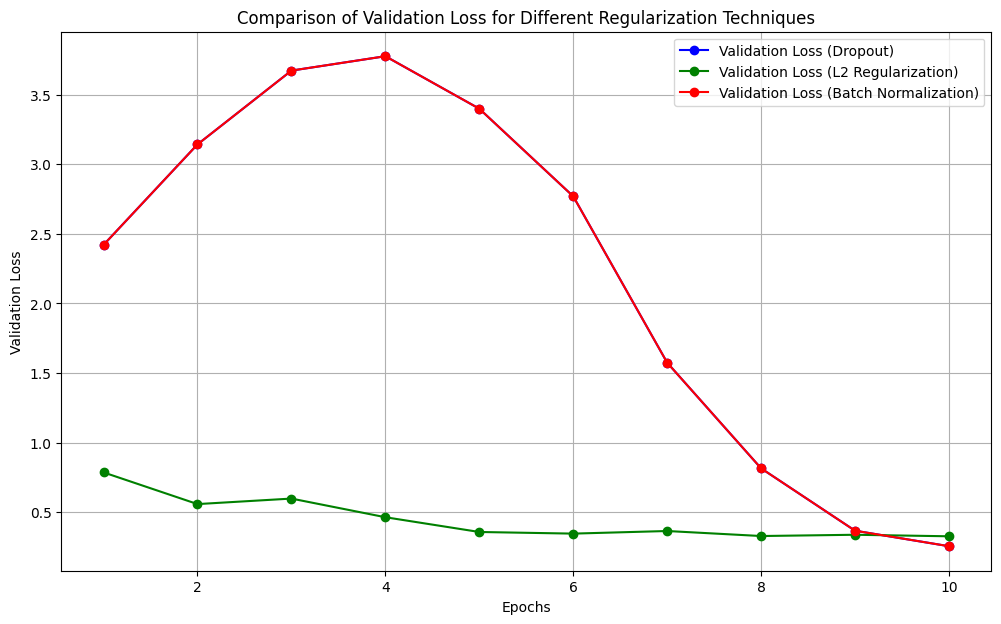

In [ ]:
plt.figure(figsize=(12, 7))

# Plot Validation Loss for Dropout model (from previous 'history' variable)
plt.plot(range(1, len(train_loss) + 1), val_loss, 'bo-', label='Validation Loss (Dropout)')

# Plot Validation Loss for L2 Regularization model (from 'val_loss_l2' variable)
plt.plot(range(1, len(train_loss_l2) + 1), val_loss_l2, 'go-', label='Validation Loss (L2 Regularization)')

# Get Validation Loss for Batch Normalization model (from the latest 'history' variable)
bn_val_loss = history.history['val_loss']
bn_epochs = range(1, len(bn_val_loss) + 1)
plt.plot(bn_epochs, bn_val_loss, 'ro-', label='Validation Loss (Batch Normalization)')

plt.title('Comparison of Validation Loss for Different Regularization Techniques')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True)
plt.show()